<a href="https://colab.research.google.com/github/eli899/ProyectoIA/blob/main/copia_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import time
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50, MobileNetV2, DenseNet121
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from PIL import Image

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
FINE_TUNE_EPOCHS = 8
LEARNING_RATE = 1e-4
FINE_TUNE_LR = 1e-5

DATA_DIR = DATA_DIR = "/content/drive/MyDrive/Codigo de IA CP2/Dataset"

OUTPUT_DIR = '/content/drive/MyDrive/resultados_cnn_mango'
os.makedirs(OUTPUT_DIR, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('GPU disponible:', tf.config.list_physical_devices('GPU'))
print('Dataset:', DATA_DIR)
print('Resultados:', OUTPUT_DIR)

TensorFlow: 2.20.0
GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Dataset: /content/drive/MyDrive/Codigo de IA CP2/Dataset
Resultados: /content/drive/MyDrive/resultados_cnn_mango


In [ ]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def looks_like_image_dataset(path):
    path = Path(path)
    if not path.exists() or not path.is_dir():
        return False
    class_dirs = [d for d in path.iterdir() if d.is_dir()]
    if len(class_dirs) < 2:
        return False
    image_count = 0
    for d in class_dirs:
        image_count += sum(1 for f in d.rglob('*') if f.suffix.lower() in IMAGE_EXTENSIONS)
    return image_count >= 20

if not looks_like_image_dataset(DATA_DIR):
    print('No se encontro dataset en DATA_DIR. Buscando en MyDrive...')
    candidates = []
    for root, dirs, files in os.walk('/content/drive/MyDrive'):
        root_path = Path(root)
        if looks_like_image_dataset(root_path):
            candidates.append(str(root_path))
            print('Candidato:', root_path)
        if len(candidates) >= 10:
            break
    if candidates:
        DATA_DIR = candidates[0]
        print('Usando automaticamente:', DATA_DIR)
    else:
        raise FileNotFoundError('No se encontro una carpeta de dataset. Revisa DATA_DIR.')
else:
    print('Dataset encontrado correctamente:', DATA_DIR)

Dataset encontrado correctamente: /content/drive/MyDrive/Codigo de IA CP2/Dataset




# 4. Analisis del dataset
Calcula numero de imagenes, clases, distribucion por clase y resoluciones de muestra. Estos valores se usan en la descripcion del dataset del documento.

Total de imagenes: 4000
Numero de clases: 8
Clases: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


,imagenes
label,
Anthracnose,500
Bacterial Canker,500
Cutting Weevil,500
Die Back,500
Gall Midge,500
Healthy,500
Powdery Mildew,500
Sooty Mould,500


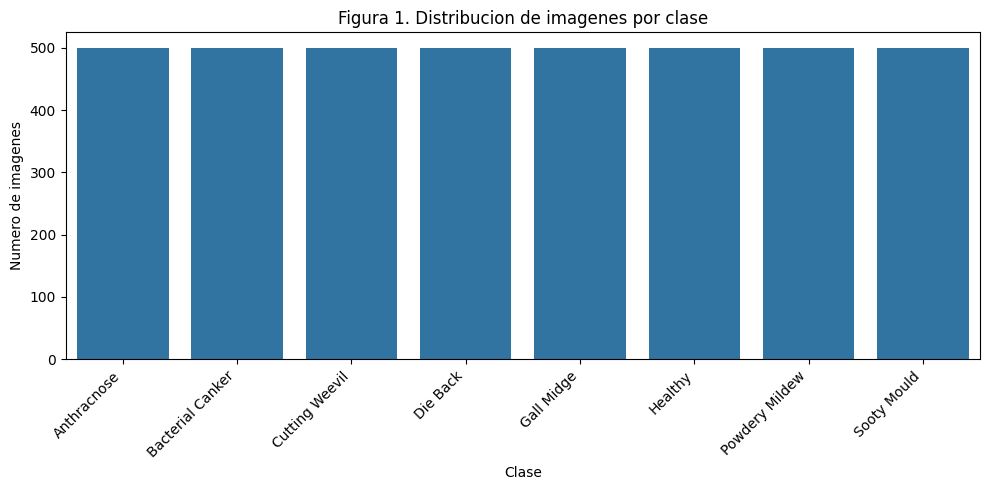

,width,height
count,50.00000,50.000000
mean,267.20000,267.180000
std,38.28145,38.296209
min,240.00000,239.000000
25%,240.00000,240.000000
50%,240.00000,240.000000
75%,320.00000,320.000000
max,320.00000,320.000000


In [ ]:
def collect_image_paths(data_dir):
    rows = []
    data_dir = Path(data_dir)
    for class_dir in sorted([d for d in data_dir.iterdir() if d.is_dir()]):
        for img_path in class_dir.rglob('*'):
            if img_path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({'path': str(img_path), 'label': class_dir.name})
    return pd.DataFrame(rows)

df = collect_image_paths(DATA_DIR)
if df.empty:
    raise ValueError('No se encontraron imagenes. Verifica que el dataset tenga carpetas por clase.')

class_names = sorted(df['label'].unique())
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}
df['label_idx'] = df['label'].map(class_to_index)

print('Total de imagenes:', len(df))
print('Numero de clases:', len(class_names))
print('Clases:', class_names)

class_counts = df['label'].value_counts().sort_index()
display(class_counts.to_frame('imagenes'))

plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title('Figura 1. Distribucion de imagenes por clase')
plt.xlabel('Clase')
plt.ylabel('Numero de imagenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figura_1_distribucion_clases.png'), dpi=300)
plt.show()

sample_paths = df['path'].sample(min(50, len(df)), random_state=SEED).tolist()
sizes = []
for p in sample_paths:
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception:
        pass
if sizes:
    sizes_df = pd.DataFrame(sizes, columns=['width', 'height'])
    display(sizes_df.describe())




# 5. Visualizacion de imagenes del dataset




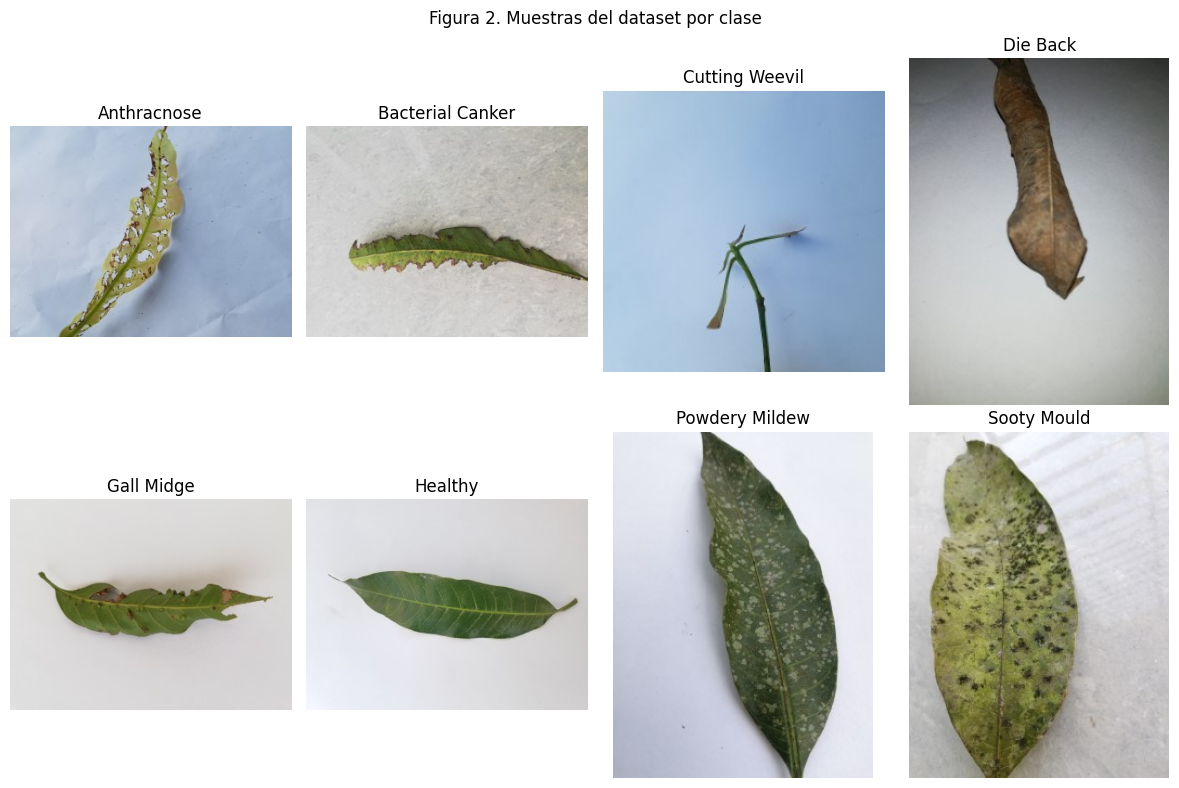

In [ ]:
n = min(8, len(class_names))
plt.figure(figsize=(12, 8))
for i, (_, row) in enumerate(df.groupby('label', group_keys=False).sample(1, random_state=SEED).head(n).iterrows()):
    img = Image.open(row['path']).convert('RGB')
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(row['label'])
    plt.axis('off')
plt.suptitle('Figura 2. Muestras del dataset por clase')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figura_2_muestras_dataset.png'), dpi=300)
plt.show()




# 6. Division train, validation y test
Division estratificada:
70% entrenamiento
15% validacion
15% prueba:




In [ ]:
import math
import shutil

SRC_DIR = Path(DATA_DIR)
DST_DIR = Path('/content/mango_leaves')

def is_image(p):
    return p.suffix.lower() in {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Se borra solo la copia temporal en Colab, no el dataset original de Drive.
if DST_DIR.exists():
    shutil.rmtree(DST_DIR)

classes = sorted([d.name for d in SRC_DIR.iterdir() if d.is_dir()])
print('Clases encontradas:', classes)

for split in ['train', 'val', 'test']:
    for class_name in classes:
        (DST_DIR / split / class_name).mkdir(parents=True, exist_ok=True)

split_rows = []

for class_name in classes:
    imgs = [p for p in (SRC_DIR / class_name).glob('**/*') if p.is_file() and is_image(p)]
    random.shuffle(imgs)
    n = len(imgs)
    n_train = math.floor(0.70 * n)
    n_val = math.floor(0.15 * n)

    split_data = {
        'train': imgs[:n_train],
        'validation': imgs[n_train:n_train + n_val],
        'test': imgs[n_train + n_val:]
    }

    for split_name, subset in split_data.items():
        folder_name = 'val' if split_name == 'validation' else split_name
        for idx, src_path in enumerate(subset):
            dst_path = DST_DIR / folder_name / class_name / src_path.name
            if dst_path.exists():
                dst_path = DST_DIR / folder_name / class_name / f'{src_path.stem}_{idx}{src_path.suffix}'
            shutil.copy2(src_path, dst_path)
            split_rows.append({
                'path': str(dst_path),
                'original_path': str(src_path),
                'label': class_name,
                'split': split_name
            })

split_df = pd.DataFrame(split_rows)
class_names = classes
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}
split_df['label_idx'] = split_df['label'].map(class_to_index)

train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df = split_df[split_df['split'] == 'validation'].reset_index(drop=True)
test_df = split_df[split_df['split'] == 'test'].reset_index(drop=True)

print('Division completada en:', DST_DIR)
print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

split_summary = pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'validation': val_df['label'].value_counts().sort_index(),
    'test': test_df['label'].value_counts().sort_index()
}).fillna(0).astype(int)

display(split_summary)
split_summary.to_csv(os.path.join(OUTPUT_DIR, 'tabla_distribucion_train_val_test.csv'))

Clases encontradas: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Division completada en: /content/mango_leaves
Train: 2800
Validation: 600
Test: 600


,train,validation,test
label,,,
Anthracnose,350,75,75
Bacterial Canker,350,75,75
Cutting Weevil,350,75,75
Die Back,350,75,75
Gall Midge,350,75,75
Healthy,350,75,75
Powdery Mildew,350,75,75
Sooty Mould,350,75,75


7. Preprocesamiento y aumento de datos
Se aplican redimensionamiento a 224 x 224, lectura RGB, conversion de etiquetas a numeros y aumento de datos para entrenamiento.

In [ ]:
IMG_SIZE_224 = (224, 224)
BATCH = BATCH_SIZE
AUTOTUNE = tf.data.AUTOTUNE

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DST_DIR / 'train',
    image_size=IMG_SIZE_224,
    batch_size=BATCH,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DST_DIR / 'val',
    image_size=IMG_SIZE_224,
    batch_size=BATCH,
    shuffle=False,
    seed=SEED
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DST_DIR / 'test',
    image_size=IMG_SIZE_224,
    batch_size=BATCH,
    shuffle=False,
    seed=SEED
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
class_to_index = {name: i for i, name in enumerate(class_names)}
index_to_class = {i: name for name, i in class_to_index.items()}

print('class_names =', class_names)
print('NUM_CLASSES =', NUM_CLASSES)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name='data_augmentation')

def prepare(ds, training=False):
    ds = ds.cache()
    if training:
        ds = ds.shuffle(1000, seed=SEED)
    return ds.prefetch(AUTOTUNE)

train_ds = prepare(train_ds, training=True)
val_ds = prepare(val_ds)
test_ds = prepare(test_ds)

Found 2800 files belonging to 8 classes.
Found 600 files belonging to 8 classes.
Found 600 files belonging to 8 classes.
class_names = ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
NUM_CLASSES = 8


7.1 Visualizacion del aumento de datos




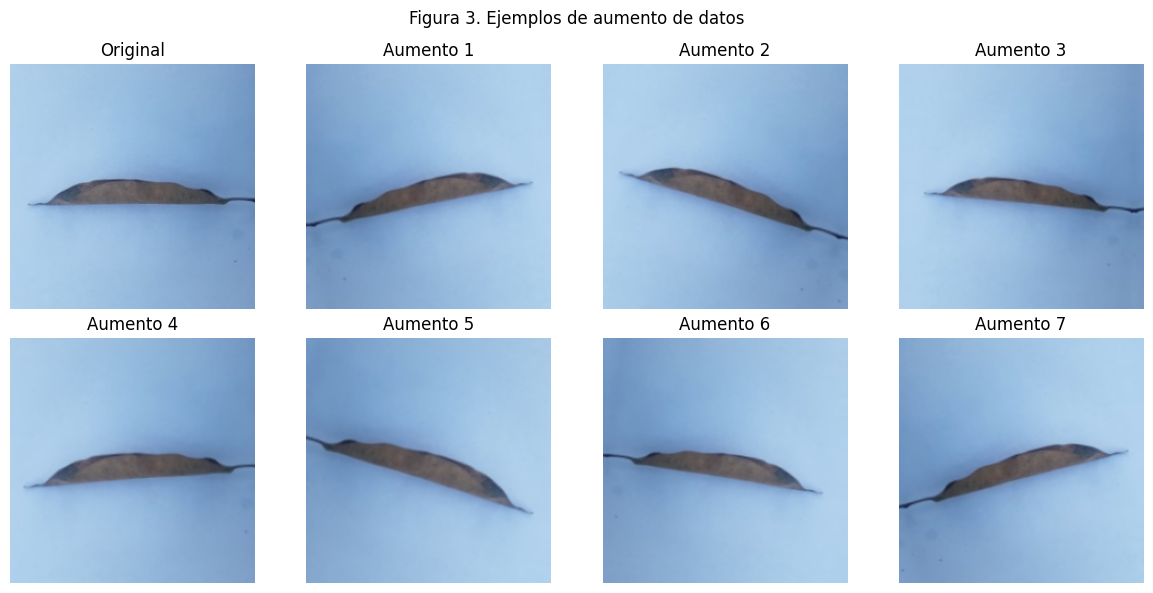

In [ ]:
sample_row = train_df.sample(1, random_state=SEED).iloc[0]
original_img = Image.open(sample_row['path']).convert('RGB').resize(IMG_SIZE)
original_array = np.array(original_img).astype(np.float32)

plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(original_img)
plt.title('Original')
plt.axis('off')

for i in range(7):
    augmented = data_augmentation(tf.expand_dims(original_array, axis=0), training=True)[0].numpy()
    augmented = np.clip(augmented, 0, 255).astype('uint8')
    plt.subplot(2, 4, i + 2)
    plt.imshow(augmented)
    plt.title(f'Aumento {i + 1}')
    plt.axis('off')

plt.suptitle('Figura 3. Ejemplos de aumento de datos')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'figura_3_aumento_datos.png'), dpi=300)
plt.show()

In [ ]:
import os

archivos = [
    "MobileNetV2_pesos.weights.h5",
    "DenseNet121_pesos.weights.h5",
    "ResNet50_pesos.weights.h5"
]

print("Carpeta:", OUTPUT_DIR)

for archivo in archivos:
    ruta = os.path.join(OUTPUT_DIR, archivo)
    print(f"{archivo}: {os.path.exists(ruta)}")

Carpeta: /content/drive/MyDrive/resultados_cnn_mango
MobileNetV2_pesos.weights.h5: True
DenseNet121_pesos.weights.h5: True
ResNet50_pesos.weights.h5: True


8. Arquitecturas CNN propuestas
Se usa Transfer Learning con ImageNet. Primero se congela la base convolucional y luego se aplica fine tuning en las ultimas capas.

In [ ]:
HEAD_EPOCHS = 12
FINE_TUNE_EPOCHS = 20
HEAD_LR = 1e-3
FINE_TUNE_LR = 1e-4
WEIGHT_DECAY = 1e-5
DROPOUT_RATE = 0.4

loss_fn = tf.keras.losses.SparseCategoricalCrossentropy()
metrics = [tf.keras.metrics.SparseCategoricalAccuracy(name='accuracy')]

def classifier_head(x, num_classes):
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return outputs

def build_transfer_model(model_name, base_model_fn, preprocess_fn, input_shape=(224, 224, 3)):
    base_model = base_model_fn(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = layers.Lambda(preprocess_fn, name=f'{model_name}_preprocess')(x)
    x = base_model(x, training=False)
    outputs = classifier_head(x, len(class_names))

    model = models.Model(inputs, outputs, name=f'{model_name}_mango')
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=HEAD_LR,weight_decay=WEIGHT_DECAY),
        loss=loss_fn,
        metrics=metrics
    )
    return model, base_model

def get_callbacks(model_name, stage):
    model_dir = os.path.join(OUTPUT_DIR, model_name)
    os.makedirs(model_dir, exist_ok=True)
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            mode='max'
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=os.path.join(model_dir, f'{model_name}_{stage}_best.keras'),
            monitor='val_accuracy',
            save_best_only=True,
            mode='max'
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_accuracy',
            factor=0.5,
            patience=3,
            min_lr=1e-6,
            mode='max',
            verbose=1
        )
    ]

def combine_histories(history_head, history_ft):
    combined = {}
    all_keys = set(history_head.history.keys()) | set(history_ft.history.keys())
    for key in all_keys:
        combined[key] = history_head.history.get(key, []) + history_ft.history.get(key, [])
    return combined

def train_two_stage_model(model_name, model, base_model, train_ds, val_ds, unfreeze_layers):
    start = time.time()

    print(f'\n[1/2] {model_name}: entrenando solo la cabeza')
    history_head = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=HEAD_EPOCHS,
        callbacks=get_callbacks(model_name, 'head'),
        verbose=1
    )

    print(f'\n[2/2] {model_name}: fine-tuning de las ultimas {unfreeze_layers} capas')
    base_model.trainable = True
    for layer in base_model.layers[:-unfreeze_layers]:
        layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=FINE_TUNE_LR, weight_decay=WEIGHT_DECAY),
        loss=loss_fn,
        metrics=metrics
    )

    history_ft = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=FINE_TUNE_EPOCHS,
        callbacks=get_callbacks(model_name, 'fine_tuning'),
        verbose=1
    )

    total_time = time.time() - start
    combined_history = combine_histories(history_head, history_ft)

    model.save(os.path.join(OUTPUT_DIR, f'{model_name}_modelo_final.keras'))
    model.save_weights(
    os.path.join(
        OUTPUT_DIR,
        f"{model_name}_pesos.weights.h5"
    )
)
    with open(os.path.join(OUTPUT_DIR, f'{model_name}_history.json'), 'w') as f:
        json.dump(combined_history, f)

    models_built[model_name] = {'model': model, 'base_model': base_model}
    histories[model_name] = combined_history
    training_times[model_name] = total_time

    print(f'Tiempo de entrenamiento {model_name}: {total_time/60:.2f} minutos')
    return history_head, history_ft

models_built = {}
histories = {}
training_times = {}

print('Funciones de arquitectura y entrenamiento listas.')

Funciones de arquitectura y entrenamiento listas.


9. Callbacks e hiperparametros
Se usan EarlyStopping, ModelCheckpoint y ReduceLROnPlateau.

In [ ]:
hyperparams = pd.DataFrame([
    {'hiperparametro': 'Tamano de imagen', 'valor': f'{IMG_SIZE[0]} x {IMG_SIZE[1]}'},
    {'hiperparametro': 'Batch size', 'valor': BATCH_SIZE},
    {'hiperparametro': 'Epocas head training', 'valor': HEAD_EPOCHS},
    {'hiperparametro': 'Epocas fine tuning', 'valor': FINE_TUNE_EPOCHS},
    {'hiperparametro': 'Learning rate head', 'valor': HEAD_LR},
    {'hiperparametro': 'Learning rate fine tuning', 'valor': FINE_TUNE_LR},
    {'hiperparametro': 'Optimizador', 'valor': 'AdamW'},
    {'hiperparametro': 'Weight decay', 'valor': WEIGHT_DECAY},
    {'hiperparametro': 'Funcion de perdida', 'valor': 'Sparse categorical crossentropy'},
    {'hiperparametro': 'Dropout', 'valor': DROPOUT_RATE},
    {'hiperparametro': 'Activacion final', 'valor': 'Softmax'},
    {'hiperparametro': 'Capas descongeladas ResNet50', 'valor': 50},
    {'hiperparametro': 'Capas descongeladas MobileNetV2', 'valor': 30},
    {'hiperparametro': 'Capas descongeladas DenseNet121', 'valor': 60},
])
display(hyperparams)
hyperparams.to_csv(os.path.join(OUTPUT_DIR, 'tabla_hiperparametros.csv'), index=False)

,hiperparametro,valor
0,Tamano de imagen,224 x 224
1,Batch size,32
2,Epocas head training,12
3,Epocas fine tuning,20
4,Learning rate head,0.001
5,Learning rate fine tuning,0.0001
6,Optimizador,AdamW
7,Weight decay,0.00001
8,Funcion de perdida,Sparse categorical crossentropy
9,Dropout,0.4


10. Entrenamiento de ResNet50, MobileNetV2 y DenseNet121
Activa GPU en Colab: Entorno de ejecucion > Cambiar tipo de entorno de ejecucion > GPU.

In [ ]:
weights_path = os.path.join(
    OUTPUT_DIR,
    "ResNet50_pesos.weights.h5"
)

resnet_model, resnet_base = build_transfer_model(
    model_name='ResNet50',
    base_model_fn=ResNet50,
    preprocess_fn=resnet_preprocess,
    input_shape=(224, 224, 3)
)

print('ResNet50 parametros:', resnet_model.count_params())

if os.path.exists(weights_path):

    resnet_model.load_weights(weights_path)

    models_built['ResNet50'] = {
        'model': resnet_model,
        'base_model': resnet_base
    }

    print(" ResNet50 cargado correctamente.")

else:

    print(" No se encontraron los pesos. Entrenando...")

    h1_resnet, h2_resnet = train_two_stage_model(
        model_name='ResNet50',
        model=resnet_model,
        base_model=resnet_base,
        train_ds=train_ds,
        val_ds=val_ds,
        unfreeze_layers=80
    )

ResNet50 parametros: 23604104
 ResNet50 cargado correctamente.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 126 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10.2 Entrenamiento de MobileNetV2
MobileNetV2 es una arquitectura liviana. Se descongelan las ultimas 30 capas para fine tuning.

In [ ]:
weights_path = os.path.join(
    OUTPUT_DIR,
    "MobileNetV2_pesos.weights.h5"
)

mobilenet_model, mobilenet_base = build_transfer_model(
    model_name='MobileNetV2',
    base_model_fn=MobileNetV2,
    preprocess_fn=mobilenet_preprocess,
    input_shape=(224, 224, 3)
)

print('MobileNetV2 parametros:', mobilenet_model.count_params())

if os.path.exists(weights_path):
    mobilenet_model.load_weights(weights_path)

    models_built['MobileNetV2'] = {
        'model': mobilenet_model,
        'base_model': mobilenet_base
    }

    print(" MobileNetV2 cargado correctamente.")

else:
    print(" No se encontraron los pesos. Entrenando...")

    h1_mobile, h2_mobile = train_two_stage_model(
        model_name='MobileNetV2',
        model=mobilenet_model,
        base_model=mobilenet_base,
        train_ds=train_ds,
        val_ds=val_ds,
        unfreeze_layers=40
    )

MobileNetV2 parametros: 2268232
 MobileNetV2 cargado correctamente.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 88 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


10.3 Entrenamiento de DenseNet121
DenseNet121 reutiliza caracteristicas entre capas. Se descongelan las ultimas 60 capas para fine tuning.

In [ ]:
weights_path = os.path.join(
    OUTPUT_DIR,
    "DenseNet121_pesos.weights.h5"
)

densenet_model, densenet_base = build_transfer_model(
    model_name='DenseNet121',
    base_model_fn=DenseNet121,
    preprocess_fn=densenet_preprocess,
    input_shape=(224, 224, 3)
)

print('DenseNet121 parametros:', densenet_model.count_params())

if os.path.exists(weights_path):

    densenet_model.load_weights(weights_path)

    models_built['DenseNet121'] = {
        'model': densenet_model,
        'base_model': densenet_base
    }

    print(" DenseNet121 cargado correctamente.")

else:

    print(" No se encontraron los pesos. Entrenando...")

    h1_dense, h2_dense = train_two_stage_model(
        model_name='DenseNet121',
        model=densenet_model,
        base_model=densenet_base,
        train_ds=train_ds,
        val_ds=val_ds,
        unfreeze_layers=60
    )

DenseNet121 parametros: 7045704
 DenseNet121 cargado correctamente.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adamw', because it has 2 variables whereas the saved optimizer has 108 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
import os

for modelo in ["MobileNetV2","DenseNet121","ResNet50"]:

    ruta = os.path.join(
        OUTPUT_DIR,
        f"{modelo}_modelo_final.keras"
    )

    if os.path.exists(ruta):
        print(f" {modelo} guardado correctamente")
    else:
        print(f" Falta {modelo}")

 MobileNetV2 guardado correctamente
 DenseNet121 guardado correctamente
 ResNet50 guardado correctamente


In [ ]:
import os

archivos = [
    "MobileNetV2_modelo_final.keras",
    "DenseNet121_modelo_final.keras",
    "ResNet50_modelo_final.keras",
    "MobileNetV2_pesos.weights.h5",
    "DenseNet121_pesos.weights.h5",
    "ResNet50_pesos.weights.h5"
]

for archivo in archivos:
    ruta = os.path.join(OUTPUT_DIR, archivo)

    if os.path.exists(ruta):
        print(f" {archivo}")
    else:
        print(f" {archivo}")

 MobileNetV2_modelo_final.keras
 DenseNet121_modelo_final.keras
 ResNet50_modelo_final.keras
 MobileNetV2_pesos.weights.h5
 DenseNet121_pesos.weights.h5
 ResNet50_pesos.weights.h5



10.4 Verificacion de modelos entrenados
Esta celda confirma que las tres arquitecturas quedaron registradas para generar curvas, matrices y tablas comparativas.

In [ ]:
print('Modelos entrenados:', list(models_built.keys()))
print('Historias disponibles:', list(histories.keys()))
print('Tiempos de entrenamiento:')
for name, seconds in training_times.items():
    print(f'{name}: {seconds/60:.2f} minutos')

Modelos entrenados: ['ResNet50', 'MobileNetV2', 'DenseNet121']
Historias disponibles: []
Tiempos de entrenamiento:


In [ ]:
if 'histories' in locals() or 'histories' in globals():
    print('Keys in histories:', histories.keys())
else:
    print('The variable \'histories\' does not exist. Please run the training cell (ID MdsujrNEjV_d) first.')

Keys in histories: dict_keys(['ResNet50', 'MobileNetV2', 'DenseNet121'])


In [ ]:
print('GPU disponible:', tf.config.list_physical_devices('GPU'))

GPU disponible: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


11. Curvas de accuracy y loss

In [ ]:
import json
import os

# Cargar los historiales guardados
histories = {}

modelos = [
    "MobileNetV2",
    "DenseNet121",
    "ResNet50"
]

for modelo in modelos:
    history_path = os.path.join(OUTPUT_DIR, f"{modelo}_history.json")

    if os.path.exists(history_path):
        with open(history_path, "r") as f:
            histories[modelo] = json.load(f)

        print(f" Historial cargado: {modelo}")

    else:
        print(f" No existe el historial de {modelo}")

 Historial cargado: MobileNetV2
 Historial cargado: DenseNet121
 Historial cargado: ResNet50


In [ ]:
def get_metric_series(history, preferred, fallback):
    if preferred in history:
        return history[preferred]
    elif fallback in history:
        return history[fallback]
    else:
        return []


def plot_history(history, model_name):

    train_acc = get_metric_series(history, "accuracy", "acc")
    val_acc = get_metric_series(history, "val_accuracy", "val_acc")

    train_loss = history["loss"]
    val_loss = history["val_loss"]

    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(epochs, train_acc, label="Training accuracy")
    plt.plot(epochs, val_acc, label="Validation accuracy")
    plt.title(f"Accuracy - {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(epochs, train_loss, label="Training loss")
    plt.plot(epochs, val_loss, label="Validation loss")
    plt.title(f"Loss - {model_name}")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.legend()

    plt.suptitle(f"Curvas de entrenamiento de {model_name}")

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            OUTPUT_DIR,
            f"curvas_{model_name}.png"
        ),
        dpi=300
    )

    plt.show()


for nombre, history in histories.items():
    plot_history(history, nombre)

Acuari General

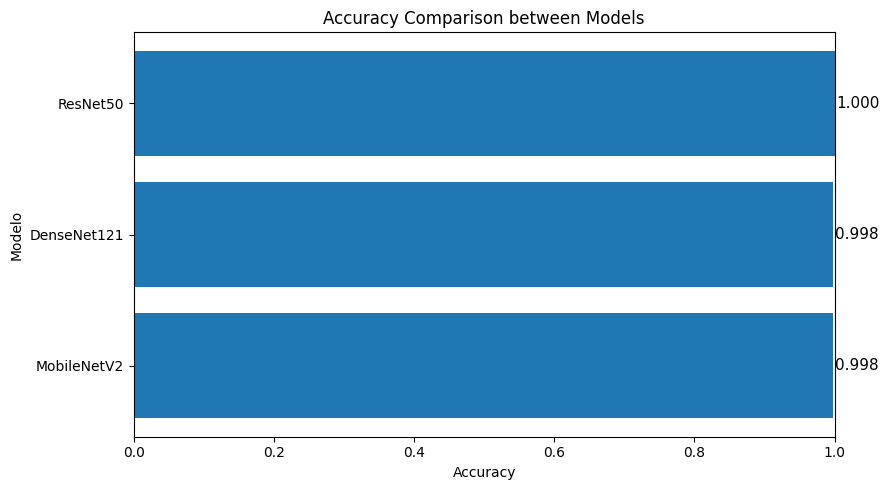

In [ ]:
accuracy_df = results_df.copy().sort_values("accuracy", ascending=True)

plt.figure(figsize=(9, 5))
bars = plt.barh(
    accuracy_df["modelo"],
    accuracy_df["accuracy"],
    color="#1f77b4"
)

plt.title("Accuracy Comparison between Models")
plt.xlabel("Accuracy")
plt.ylabel("Modelo")
plt.xlim(0, 1.0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "accuracy_comparison_between_models.png"), dpi=300)
plt.show()

In [ ]:
display(results_df)

,modelo,accuracy,precision,recall,f1_score,loss,tiempo_entrenamiento_min
0,ResNet50,1.000000,1.000000,1.000000,1.000000,0.000722,6.138999
2,DenseNet121,0.998333,0.998355,0.998333,0.998333,0.007934,6.706162
1,MobileNetV2,0.995000,0.995022,0.995000,0.995000,0.016356,3.020046


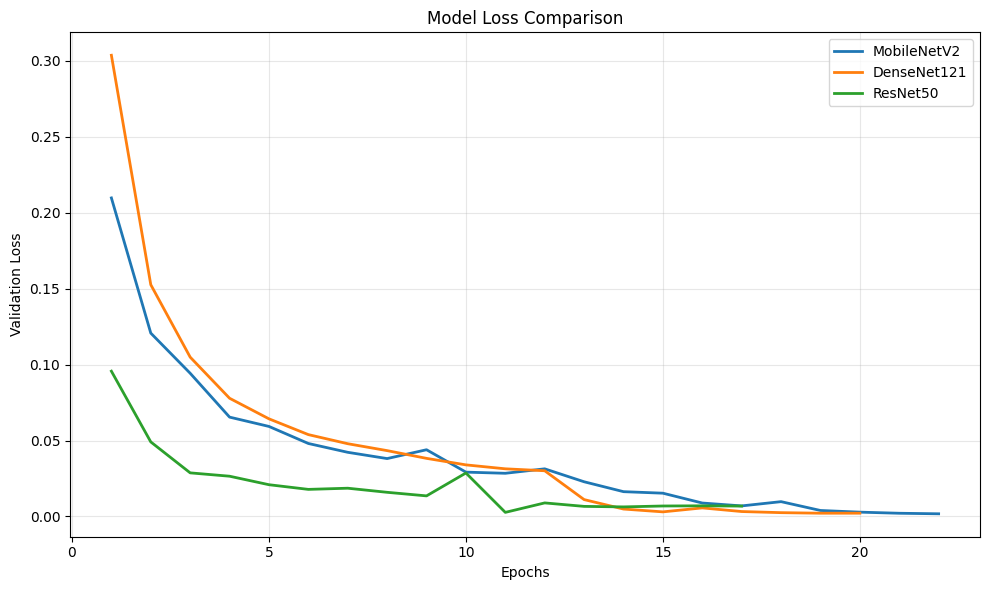

In [ ]:
plt.figure(figsize=(10, 6))

for name, history in histories.items():
    plt.plot(
        range(1, len(history["val_loss"]) + 1),
        history["val_loss"],
        linewidth=2,
        label=name
    )

plt.title("Model Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "model_loss_comparison.png"), dpi=300)
plt.show()

12. Evaluacion: accuracy, precision, recall, F1-score y loss

In [ ]:
def get_predictions(model, dataset):
    y_true, y_pred, y_prob = [], [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = np.argmax(probs, axis=1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds)
        y_prob.extend(probs)
    return np.array(y_true), np.array(y_pred), np.array(y_prob)

results = []
for name, bundle in models_built.items():
    model = bundle['model']
    test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)
    y_true, y_pred, _ = get_predictions(model, test_ds)

    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    results.append({
        'modelo': name,
        'accuracy': test_accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'loss': test_loss,
        'tiempo_entrenamiento_min': training_times.get(name, 0) / 60
    })

    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0, output_dict=True)
    report_df = pd.DataFrame(report).transpose()
    report_df.to_csv(os.path.join(OUTPUT_DIR, f'reporte_clasificacion_{name}.csv'))
    print('\nReporte de clasificacion -', name)
    display(report_df)

results_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False)
results_df.to_csv(os.path.join(OUTPUT_DIR, 'tabla_comparacion_modelos.csv'), index=False)
display(results_df)


Reporte de clasificacion - ResNet50


,precision,recall,f1-score,support
Anthracnose,1.0,1.0,1.0,75.0
Bacterial Canker,1.0,1.0,1.0,75.0
Cutting Weevil,1.0,1.0,1.0,75.0
Die Back,1.0,1.0,1.0,75.0
Gall Midge,1.0,1.0,1.0,75.0
Healthy,1.0,1.0,1.0,75.0
Powdery Mildew,1.0,1.0,1.0,75.0
Sooty Mould,1.0,1.0,1.0,75.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,600.0



Reporte de clasificacion - MobileNetV2


,precision,recall,f1-score,support
Anthracnose,0.986667,0.986667,0.986667,75.000
Bacterial Canker,1.000000,1.000000,1.000000,75.000
Cutting Weevil,1.000000,1.000000,1.000000,75.000
Die Back,1.000000,1.000000,1.000000,75.000
Gall Midge,0.986667,0.986667,0.986667,75.000
Healthy,1.000000,1.000000,1.000000,75.000
Powdery Mildew,0.986842,1.000000,0.993377,75.000
Sooty Mould,1.000000,0.986667,0.993289,75.000
accuracy,0.995000,0.995000,0.995000,0.995
macro avg,0.995022,0.995000,0.995000,600.000



Reporte de clasificacion - DenseNet121


,precision,recall,f1-score,support
Anthracnose,0.986842,1.000000,0.993377,75.000000
Bacterial Canker,1.000000,1.000000,1.000000,75.000000
Cutting Weevil,1.000000,1.000000,1.000000,75.000000
Die Back,1.000000,1.000000,1.000000,75.000000
Gall Midge,1.000000,0.986667,0.993289,75.000000
Healthy,1.000000,1.000000,1.000000,75.000000
Powdery Mildew,1.000000,1.000000,1.000000,75.000000
Sooty Mould,1.000000,1.000000,1.000000,75.000000
accuracy,0.998333,0.998333,0.998333,0.998333
macro avg,0.998355,0.998333,0.998333,600.000000


,modelo,accuracy,precision,recall,f1_score,loss,tiempo_entrenamiento_min
0,ResNet50,1.000000,1.000000,1.000000,1.000000,0.000722,0.0
2,DenseNet121,0.997778,0.998355,0.998333,0.998333,0.007934,0.0
1,MobileNetV2,0.997500,0.995022,0.995000,0.995000,0.016356,0.0


12.1: Grafico de barras de accuracy promedio por modelo
Esta figura resume la precision final de cada arquitectura y sirve para el apartado de resultados del documento.

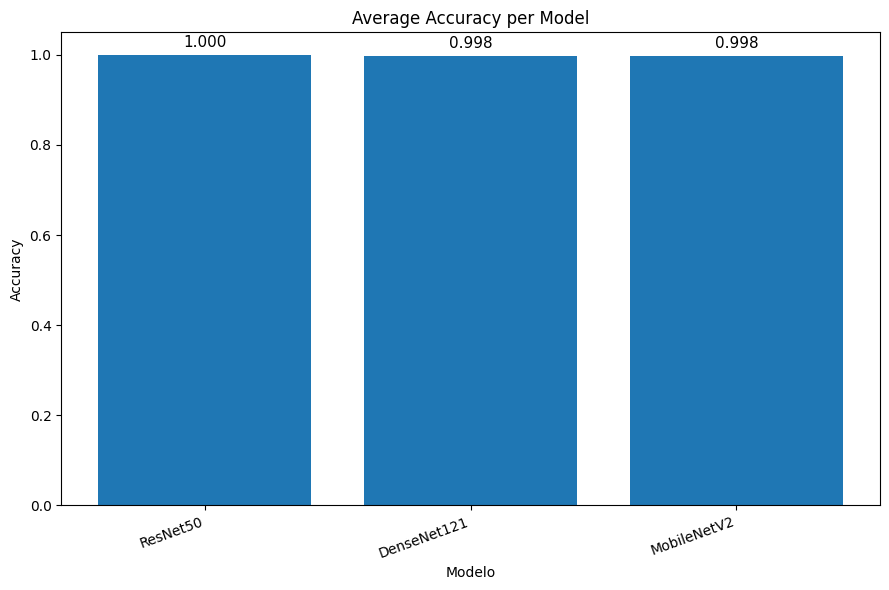

In [ ]:
accuracy_bar_df = results_df.copy().sort_values("accuracy", ascending=False)

plt.figure(figsize=(9, 6))
bars = plt.bar(
    accuracy_bar_df["modelo"],
    accuracy_bar_df["accuracy"],
    color="#1f77b4"
)

plt.title("Average Accuracy per Model")
plt.xlabel("Modelo")
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=11
    )

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "average_accuracy_por_modelo.png"), dpi=300)
plt.show()

13. Matrices de confusion

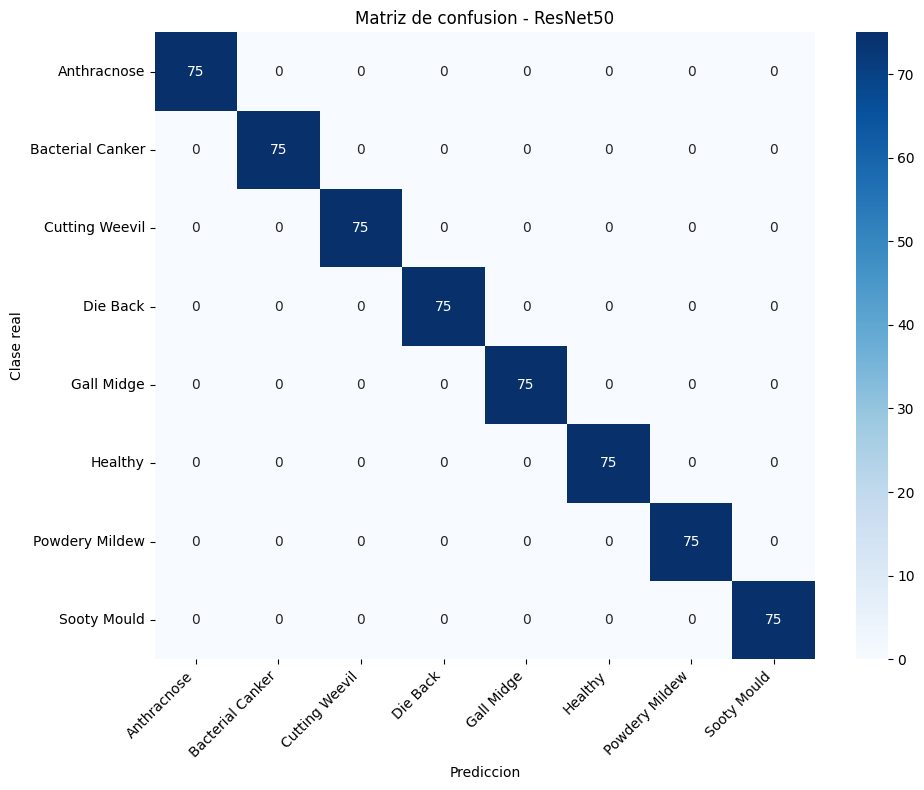

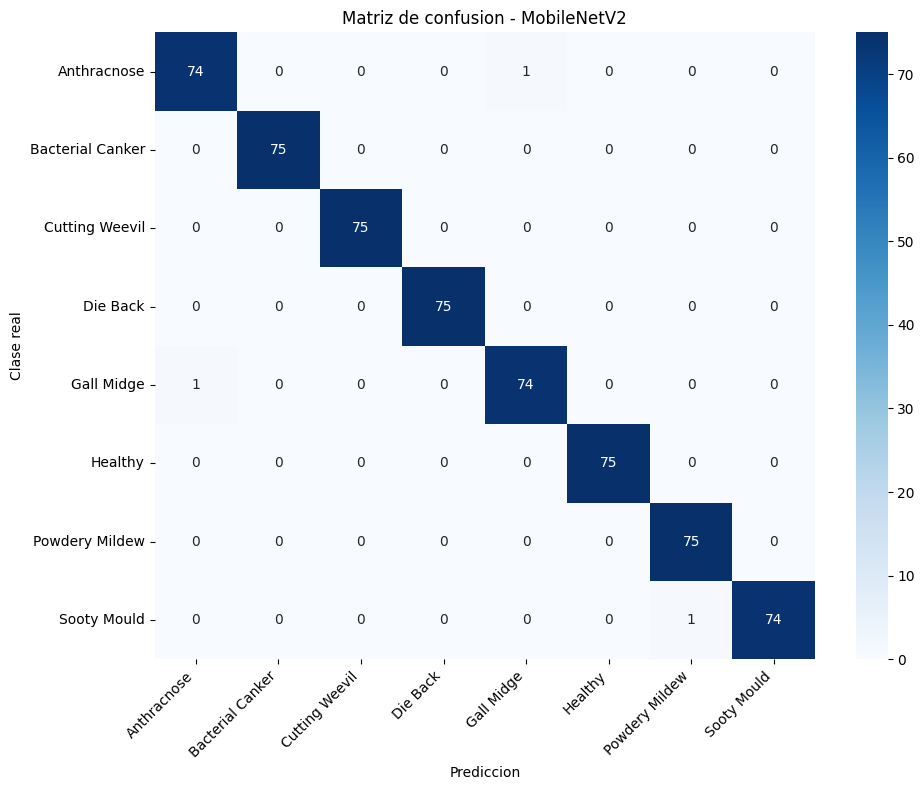

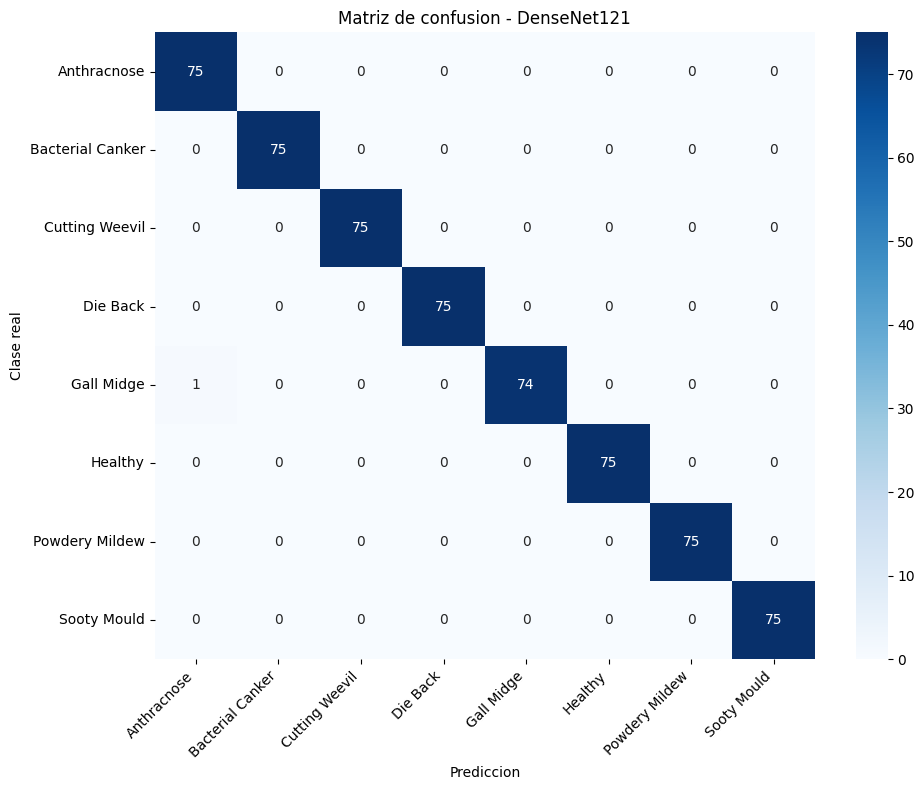

In [ ]:
for name, bundle in models_built.items():
    model = bundle['model']
    y_true, y_pred, _ = get_predictions(model, test_ds)
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Matriz de confusion - {name}')
    plt.xlabel('Prediccion')
    plt.ylabel('Clase real')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f'matriz_confusion_{name}.png'), dpi=300)
    plt.show()

14. Comparacion final de modelos

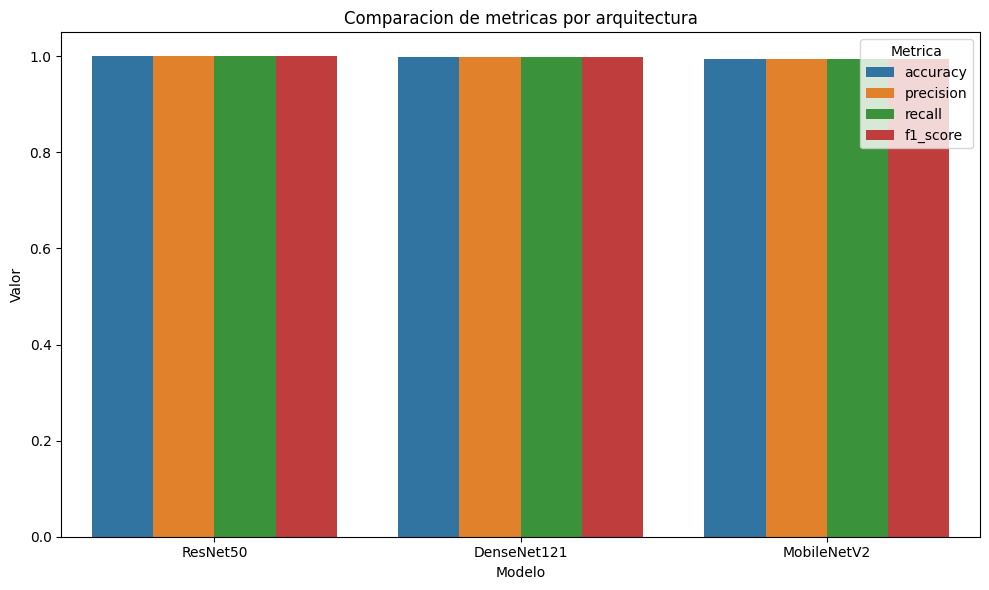

Mejor modelo segun F1-score: ResNet50


,modelo,accuracy,precision,recall,f1_score,loss,tiempo_entrenamiento_min
0,ResNet50,1.0,1.0,1.0,1.0,0.000722,6.138999


In [ ]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
plot_df = results_df.melt(id_vars='modelo', value_vars=metrics_to_plot, var_name='metrica', value_name='valor')

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x='modelo', y='valor', hue='metrica')
plt.ylim(0, 1.05)
plt.title('Comparacion de metricas por arquitectura')
plt.xlabel('Modelo')
plt.ylabel('Valor')
plt.legend(title='Metrica')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparacion_metricas_modelos.png'), dpi=300)
plt.show()

best_model_name = results_df.iloc[0]['modelo']
print('Mejor modelo segun F1-score:', best_model_name)
display(results_df.iloc[[0]])

14.1 Comparacion de precision de validacion por epoca

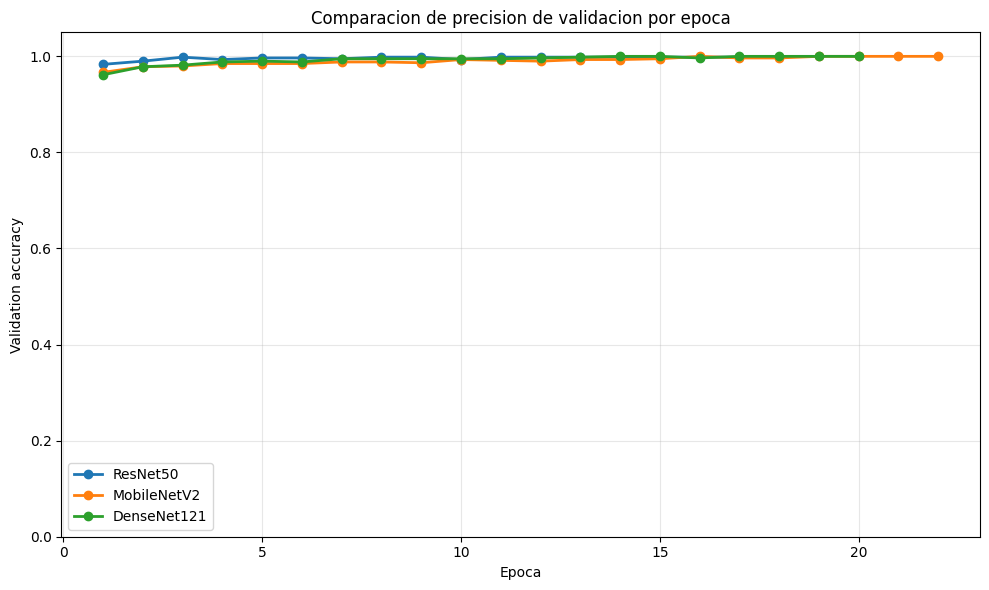

In [ ]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(range(1, len(history['val_accuracy']) + 1), history['val_accuracy'], marker='o', linewidth=2, label=name)
plt.title('Comparacion de precision de validacion por epoca')
plt.xlabel('Epoca')
plt.ylabel('Validation accuracy')
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparacion_val_accuracy_epoca.png'), dpi=300)
plt.show()

14.2 Comparacion de perdida de validacion por epoca

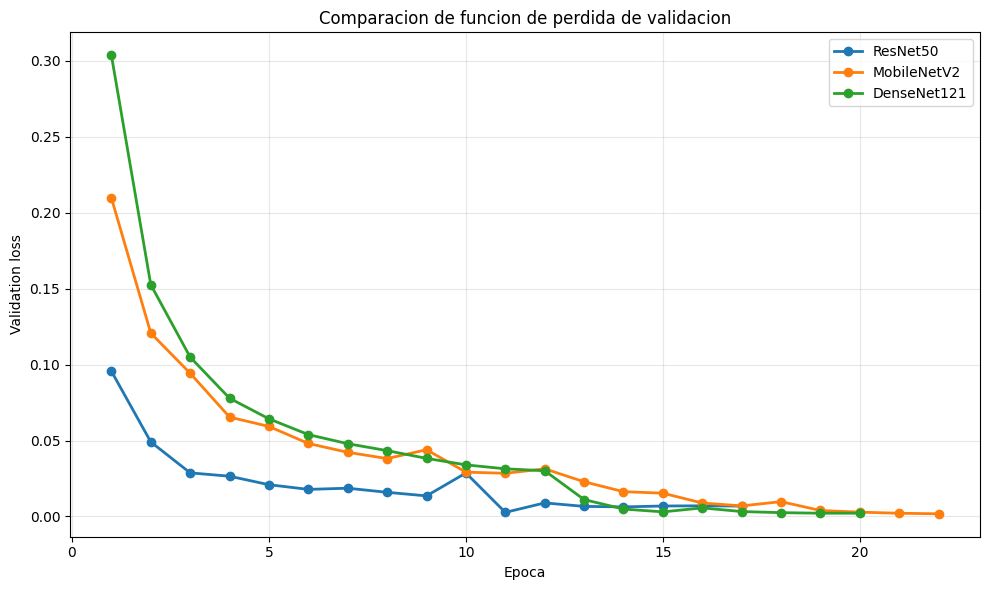

In [ ]:
plt.figure(figsize=(10, 6))
for name, history in histories.items():
    plt.plot(range(1, len(history['val_loss']) + 1), history['val_loss'], marker='o', linewidth=2, label=name)
plt.title('Comparacion de funcion de perdida de validacion')
plt.xlabel('Epoca')
plt.ylabel('Validation loss')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparacion_val_loss_epoca.png'), dpi=300)
plt.show()

14.3 Precision por clase y por modelo

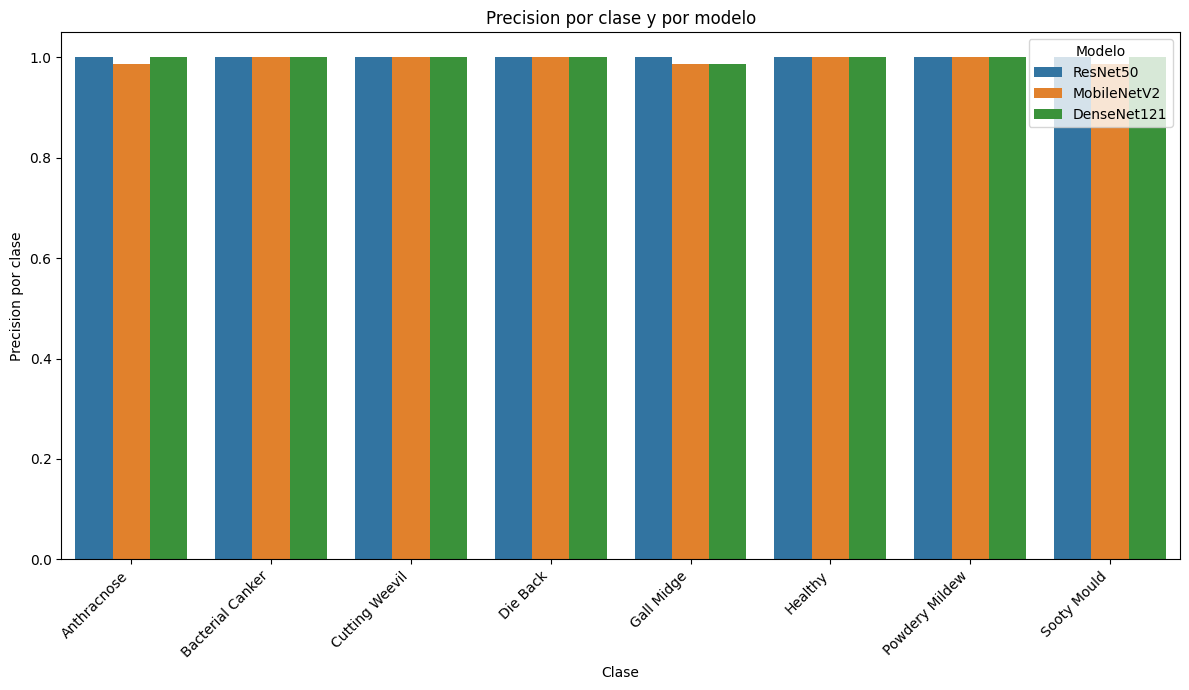

,modelo,errores_principales
0,ResNet50,Sin errores en el conjunto de prueba.
1,MobileNetV2,1 de Sooty Mould como Powdery Mildew; 1 de Gal...
2,DenseNet121,1 de Gall Midge como Anthracnose


In [ ]:
class_accuracy_rows = []
confusion_summaries = []

for name, bundle in models_built.items():
    y_true, y_pred, _ = get_predictions(bundle['model'], test_ds)
    cm = confusion_matrix(y_true, y_pred)
    row_totals = cm.sum(axis=1)
    per_class_acc = np.divide(np.diag(cm), row_totals, out=np.zeros_like(row_totals, dtype=float), where=row_totals != 0)

    for class_name, acc in zip(class_names, per_class_acc):
        class_accuracy_rows.append({'modelo': name, 'clase': class_name, 'precision_clase': acc})

    errors = []
    for i, real_class in enumerate(class_names):
        for j, pred_class in enumerate(class_names):
            if i != j and cm[i, j] > 0:
                errors.append((cm[i, j], real_class, pred_class))
    errors = sorted(errors, reverse=True)
    if errors:
        detail = '; '.join([f'{count} de {real_class} como {pred_class}' for count, real_class, pred_class in errors[:5]])
    else:
        detail = 'Sin errores en el conjunto de prueba.'
    confusion_summaries.append({'modelo': name, 'errores_principales': detail})

class_accuracy_df = pd.DataFrame(class_accuracy_rows)
class_accuracy_df.to_csv(os.path.join(OUTPUT_DIR, 'precision_por_clase_y_modelo.csv'), index=False)

plt.figure(figsize=(12, 7))
sns.barplot(data=class_accuracy_df, x='clase', y='precision_clase', hue='modelo')
plt.title('Precision por clase y por modelo')
plt.xlabel('Clase')
plt.ylabel('Precision por clase')
plt.ylim(0, 1.05)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modelo')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'precision_por_clase_y_modelo.png'), dpi=300)
plt.show()

confusion_summary_df = pd.DataFrame(confusion_summaries)
confusion_summary_df.to_csv(os.path.join(OUTPUT_DIR, 'resumen_errores_matrices_confusion.csv'), index=False)
display(confusion_summary_df)

14.4 Complejidad y tamano de los modelos

,modelo,parametros,capas_modelo_completo,tamano_archivo_MB
1,MobileNetV2,2268232,154,22.164972
2,DenseNet121,7045704,427,37.981492
0,ResNet50,23604104,175,220.174260


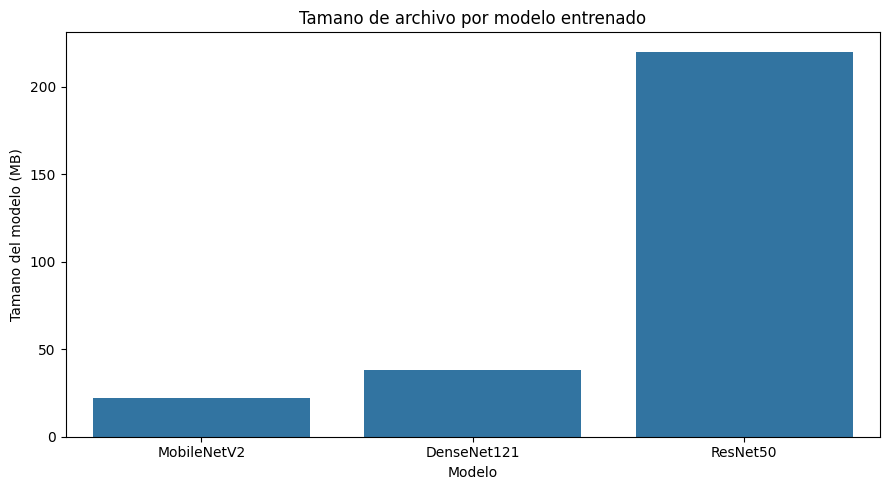

In [ ]:
complexity_rows = []
for name, bundle in models_built.items():
    model = bundle['model']
    base_model = bundle['base_model']
    model_path = os.path.join(OUTPUT_DIR, f'{name}_modelo_final.keras')
    size_mb = os.path.getsize(model_path) / (1024 * 1024) if os.path.exists(model_path) else np.nan
    complexity_rows.append({
        'modelo': name,
        'parametros': model.count_params(),
        'capas_modelo_completo': len(base_model.layers),
        'tamano_archivo_MB': size_mb
    })

complexity_df = pd.DataFrame(complexity_rows).sort_values('parametros')
complexity_df.to_csv(os.path.join(OUTPUT_DIR, 'tabla_complejidad_modelos.csv'), index=False)
display(complexity_df)

plt.figure(figsize=(9, 5))
sns.barplot(data=complexity_df, x='modelo', y='tamano_archivo_MB')
plt.title('Tamano de archivo por modelo entrenado')
plt.xlabel('Modelo')
plt.ylabel('Tamano del modelo (MB)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'tamano_modelos_mb.png'), dpi=300)
plt.show()

In [ ]:
print(results_df.sort_values("accuracy", ascending=False))

        modelo  accuracy  precision    recall  f1_score      loss  \
0     ResNet50  1.000000   1.000000  1.000000  1.000000  0.000722   
2  DenseNet121  0.998333   0.998355  0.998333  0.998333  0.007934   
1  MobileNetV2  0.995000   0.995022  0.995000  0.995000  0.016356   

   tiempo_entrenamiento_min  
0                  6.138999  
2                  6.706162  
1                  3.020046  


15. Prediccion individual con el mejor modelo

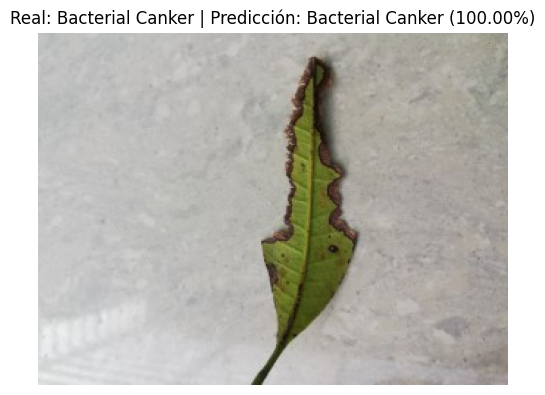

Mejor modelo seleccionado: ResNet50


In [ ]:
# Seleccionar manualmente el mejor modelo
best_model = resnet_model
best_model_name = "ResNet50"

# Seleccionar una imagen aleatoria del conjunto de prueba
sample = test_df.sample(1, random_state=SEED).iloc[0]

# Cargar y preparar la imagen
img = Image.open(sample['path']).convert('RGB')
img_resized = img.resize(IMG_SIZE)
img_array = np.array(img_resized).astype(np.float32)
img_batch = np.expand_dims(img_array, axis=0)

# Realizar la predicción
probs = best_model.predict(img_batch, verbose=0)[0]
pred_idx = int(np.argmax(probs))
pred_class = index_to_class[pred_idx]
confidence = float(probs[pred_idx])

# Mostrar resultado
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Real: {sample.label} | Predicción: {pred_class} ({confidence:.2%})")
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "prediccion_individual.png"),
    dpi=300
)

plt.show()

print(f"Mejor modelo seleccionado: {best_model_name}")

15. Prueba puntual con una imagen y top-3 de predicciones

Saving hoja 3.jpg to hoja 3 (1).jpg


,modelo,top_1_clase,top_1_probabilidad,top_2_clase,top_2_probabilidad,top_3_clase,top_3_probabilidad
0,ResNet50,Anthracnose,0.998875,Sooty Mould,0.001086,Gall Midge,0.000038
1,MobileNetV2,Anthracnose,0.859252,Gall Midge,0.078065,Sooty Mould,0.042528
2,DenseNet121,Gall Midge,0.519283,Sooty Mould,0.467117,Anthracnose,0.011670


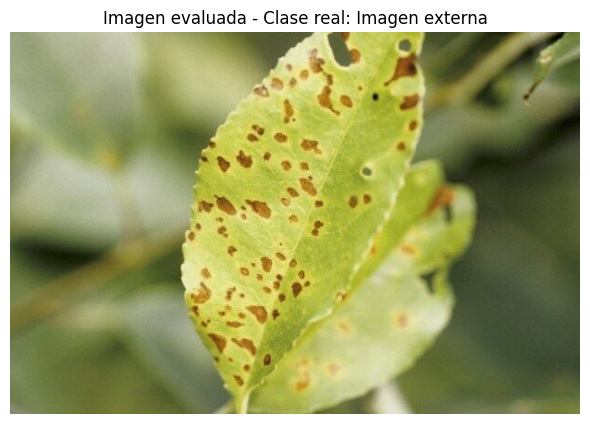

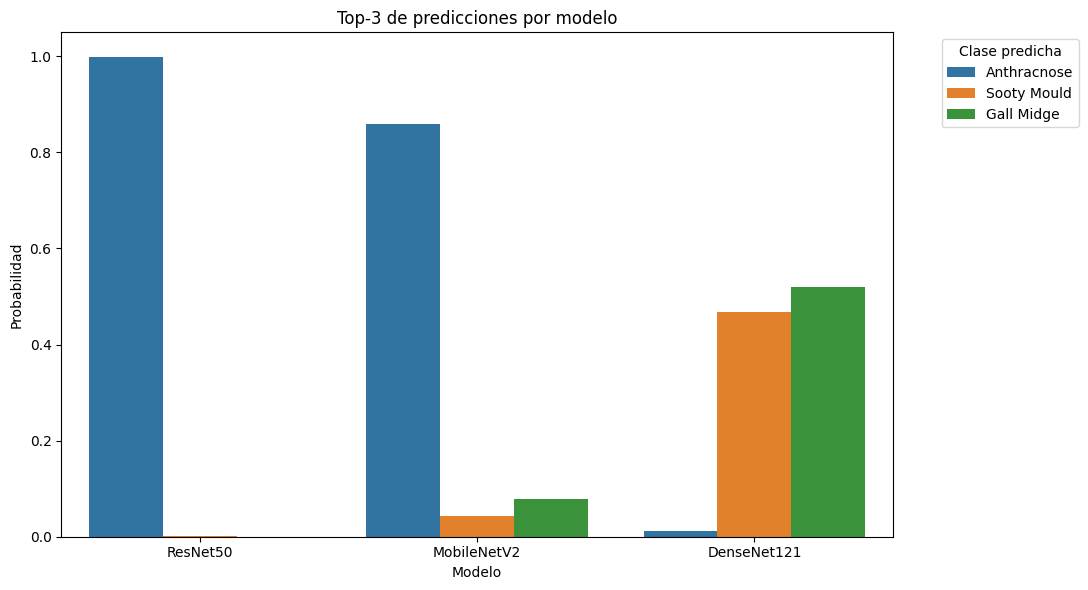

In [ ]:

try:
    from google.colab import files
    uploaded = files.upload()
except Exception:
    uploaded = {}

if uploaded:
    image_path = list(uploaded.keys())[0]
    real_label = 'Imagen externa'
else:
    sample = test_df.sample(1, random_state=SEED).iloc[0]
    image_path = sample['path']
    real_label = sample['label']

img = Image.open(image_path).convert('RGB')
img_resized = img.resize(IMG_SIZE)
img_array = np.array(img_resized).astype(np.float32)
img_batch = np.expand_dims(img_array, axis=0)

top3_rows = []
for name, bundle in models_built.items():
    probs = bundle['model'].predict(img_batch, verbose=0)[0]
    top_indices = np.argsort(probs)[-3:][::-1]
    row = {'modelo': name}
    for rank, idx in enumerate(top_indices, start=1):
        row[f'top_{rank}_clase'] = index_to_class[int(idx)]
        row[f'top_{rank}_probabilidad'] = float(probs[idx])
    top3_rows.append(row)

top3_df = pd.DataFrame(top3_rows)
top3_df.to_csv(os.path.join(OUTPUT_DIR, 'top3_predicciones_imagen.csv'), index=False)
display(top3_df)

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title(f'Imagen evaluada - Clase real: {real_label}')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'imagen_evaluada_top3.png'), dpi=300)
plt.show()

# Grafico de probabilidades top-3 por modelo
plot_rows = []
for _, row in top3_df.iterrows():
    for rank in [1, 2, 3]:
        plot_rows.append({
            'modelo': row['modelo'],
            'clase': row[f'top_{rank}_clase'],
            'probabilidad': row[f'top_{rank}_probabilidad'],
            'ranking': f'Top-{rank}'
        })
plot_top3_df = pd.DataFrame(plot_rows)

plt.figure(figsize=(11, 6))
sns.barplot(data=plot_top3_df, x='modelo', y='probabilidad', hue='clase')
plt.title('Top-3 de predicciones por modelo')
plt.xlabel('Modelo')
plt.ylabel('Probabilidad')
plt.ylim(0, 1.05)
plt.legend(title='Clase predicha', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'top3_predicciones_por_modelo.png'), dpi=300)
plt.show()

In [ ]:
!pip install -q gradio

In [ ]:
pip install gradio pillow tensorflow

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf

from PIL import Image

import pandas as pd

In [ ]:
!pip uninstall -y gradio
!pip install gradio==5.34.2

Found existing installation: gradio 5.34.2
Uninstalling gradio-5.34.2:
  Successfully uninstalled gradio-5.34.2
  Using cached gradio-5.34.2-py3-none-any.whl.metadata (16 kB)
Using cached gradio-5.34.2-py3-none-any.whl (54.3 MB)


Función de predicción

In [ ]:
import numpy as np
import tensorflow as tf
from PIL import Image

info_enfermedades = {

    "Anthracnose": {
        "descripcion": "Enfermedad causada por el hongo Colletotrichum gloeosporioides. Produce manchas oscuras en hojas, flores y frutos, afectando el desarrollo del cultivo.",
        "recomendacion": "Retirar hojas infectadas, mejorar la ventilación del cultivo y aplicar fungicidas preventivos."
    },

    "Bacterial Canker": {
        "descripcion": "Enfermedad bacteriana que ocasiona lesiones oscuras y grietas en hojas, ramas y frutos, reduciendo la productividad del árbol.",
        "recomendacion": "Eliminar las partes afectadas, desinfectar las herramientas de poda y aplicar productos bactericidas autorizados."
    },

    "Cutting Weevil": {
        "descripcion": "Plaga ocasionada por insectos que perforan y dañan las hojas, disminuyendo la capacidad fotosintética de la planta.",
        "recomendacion": "Realizar monitoreo frecuente y aplicar un control biológico o insecticidas recomendados cuando sea necesario."
    },

    "Die Back": {
        "descripcion": "Enfermedad que provoca el secado progresivo de ramas y brotes debido a hongos o condiciones de estrés.",
        "recomendacion": "Podar las ramas afectadas, evitar exceso de humedad y aplicar fungicidas adecuados."
    },

    "Gall Midge": {
        "descripcion": "Plaga que produce deformaciones y agallas en los brotes tiernos, afectando el crecimiento de la planta.",
        "recomendacion": "Eliminar brotes infestados y realizar un manejo integrado de plagas."
    },

    "Healthy": {
        "descripcion": "La hoja no presenta síntomas visibles de enfermedades o plagas y se encuentra en buen estado sanitario.",
        "recomendacion": "Mantener las buenas prácticas agrícolas y realizar inspecciones periódicas para prevenir enfermedades."
    },

    "Powdery Mildew": {
        "descripcion": "Enfermedad fúngica caracterizada por un polvo blanco sobre la superficie de las hojas que limita la fotosíntesis.",
        "recomendacion": "Aplicar fungicidas específicos y reducir la humedad excesiva en el cultivo."
    },

    "Sooty Mould": {
        "descripcion": "Hongo superficial que forma una capa negra sobre las hojas debido a la presencia de insectos productores de mielecilla.",
        "recomendacion": "Controlar los insectos responsables y limpiar las hojas afectadas para favorecer la fotosíntesis."
    }

}

# Modelo final
model = models_built["ResNet50"]["model"]

def predecir_enfermedad(imagen):

    # Convertir a RGB
    imagen = imagen.convert("RGB")

    # Redimensionar
    imagen = imagen.resize((224,224))

    # Convertir a arreglo
    img = np.array(imagen).astype(np.float32)

    # Preprocesamiento de ResNet50
    img = tf.keras.applications.resnet50.preprocess_input(img)

    # Batch
    img = np.expand_dims(img, axis=0)

    # Predicción
    pred = model.predict(img, verbose=0)[0]

    # Índice de la clase
    idx = np.argmax(pred)

    enfermedad = class_names[idx]
    confianza = float(pred[idx]) * 100

    descripcion = info_enfermedades[enfermedad]["descripcion"]
    recomendacion = info_enfermedades[enfermedad]["recomendacion"]

    # Top 3
    top3 = np.argsort(pred)[::-1][:3]

    resultados = {}

    for i in top3:
        resultados[class_names[i]] = float(pred[i])

    return (
    enfermedad,
    f"{confianza:.2f} %",
    descripcion,
    recomendacion,
    resultados
    )

Interfaz Gradio

In [ ]:
import gradio as gr



# ESTILOS DE LA INTERFAZ


css = """
.gradio-container {
    max-width: 1200px !important;
    margin: auto !important;
}

#encabezado {
    background: linear-gradient(135deg, #E8F5E9, #F5FFF6);
    border-radius: 18px;
    padding: 25px;
    margin-bottom: 20px;
    border: 1px solid #C8E6C9;
    box-shadow: 0px 4px 12px rgba(0, 0, 0, 0.08);
}

#panel-imagen,
#panel-resultados {
    border-radius: 16px;
    padding: 18px;
    border: 1px solid #DDE5DD;
    background-color: white;
    box-shadow: 0px 3px 10px rgba(0, 0, 0, 0.06);
}

#boton-analizar {
    font-size: 17px;
    font-weight: bold;
    min-height: 48px;
}

#pie-pagina {
    text-align: center;
    margin-top: 25px;
    padding: 18px;
    color: #555555;
    border-top: 1px solid #DDDDDD;
}
"""


# TEMA DE LA INTERFAZ


tema = gr.themes.Soft(
    primary_hue="green",
    secondary_hue="emerald",
    neutral_hue="slate"
)



# CREACIÓN DE LA INTERFAZ


with gr.Blocks(
    theme=tema,
    css=css,
    title="Sistema Inteligente para la Detección de Enfermedades en Hojas de Mango"
) as demo:

    # Encabezado
    gr.HTML("""
    <div id="encabezado" style="text-align:center;">

        <h1 style="color:#1B5E20; margin-bottom:10px;">
            🌿 Sistema Inteligente para la Detección de
            Enfermedades en Hojas de Mango
        </h1>

        <p style="font-size:18px; margin-bottom:8px;">
            Clasificación automática mediante
            Redes Neuronales Convolucionales
        </p>

        <p style="color:#607D68; font-size:16px;">
            Modelo utilizado:
            <b>ResNet50 con Transfer Learning</b>
        </p>

    </div>
    """)

    # Contenido principal
    with gr.Row(equal_height=True):

        # Panel izquierdo: imagen
        with gr.Column(
            scale=1,
            min_width=400,
            elem_id="panel-imagen"
        ):

            gr.Markdown("### 📷 Imagen de la hoja")

            entrada = gr.Image(
                type="pil",
                label="Suba o arrastre una imagen",
                height=390,
                sources=["upload", "webcam", "clipboard"]
            )

            boton = gr.Button(
                "🔍 Analizar imagen",
                variant="primary",
                size="lg",
                elem_id="boton-analizar"
            )

            gr.Markdown("""
            **Indicaciones:** utilice una fotografía clara, con buena
            iluminación y procure que la hoja ocupe la mayor parte
            de la imagen.
            """)

        # Panel derecho: resultados
        with gr.Column(
            scale=1,
            min_width=400,
            elem_id="panel-resultados"
        ):

            gr.Markdown("### 📋 Resultado del análisis")

            enfermedad = gr.Textbox(
                label="🌿 Enfermedad detectada",
                placeholder="Aquí aparecerá el diagnóstico",
                interactive=False
            )

            confianza = gr.Textbox(
                label="📊 Nivel de confianza",
                placeholder="Aquí aparecerá el porcentaje de confianza",
                interactive=False
            )

            descripcion = gr.Textbox(
                label="📖 Descripción de la enfermedad",
                placeholder="Aquí aparecerá la descripción",
                lines=4,
                interactive=False
            )

            recomendacion = gr.Textbox(
                label="💡 Recomendación",
                placeholder="Aquí aparecerán las recomendaciones",
                lines=4,
                interactive=False
            )

            probabilidades = gr.Label(
                num_top_classes=3,
                label="🏆 Tres predicciones principales"
            )

    # Evento del botón
    boton.click(
        fn=predecir_enfermedad,
        inputs=entrada,
        outputs=[
            enfermedad,
            confianza,
            descripcion,
            recomendacion,
            probabilidades
        ]
    )

    # Pie de página
    gr.HTML("""
    <div id="pie-pagina">

        <b>Proyecto de Inteligencia Artificial</b><br>

        Universidad Estatal de Milagro — UNEMI<br>

        Sistema basado en Redes Neuronales Convolucionales

    </div>
    """)



# EJECUCIÓN DE LA APLICACIÓN


demo.launch(
    share=True,
    inline=True,
    debug=True,
    show_error=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://eefc72372b36290b8b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
try:
    demo.close()
except:
    pass

!pip install -q --upgrade gradio

Closing server running on port: 7860


In [ ]:
import gradio as gr
print(gr.__version__)

6.20.0


In [ ]:
print(predecir_enfermedad)

<function predecir_enfermedad at 0x7fe69de72ac0>


In [ ]:
def hola(img):
    return "Funciona"

In [ ]:
print("resnet_model:", "resnet_model" in globals())
print("mobilenet_model:", "mobilenet_model" in globals())
print("densenet_model:", "densenet_model" in globals())
print("models_built:", "models_built" in globals())

if "models_built" in globals():
    print("Contenido:", models_built.keys())

resnet_model: True
mobilenet_model: True
densenet_model: True
models_built: True
Contenido: dict_keys(['ResNet50', 'MobileNetV2', 'DenseNet121'])


In [ ]:
best_model = resnet_model
print("Modelo listo:", best_model.name)

Modelo listo: ResNet50_mango


In [ ]:
print(class_names)

['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']


In [ ]:
import os
from pathlib import Path

DATA_DIR = "/content/drive/MyDrive/Codigo de IA CP2/Dataset"

# Dynamically get class names from subdirectories within DATA_DIR
clases = sorted([d.name for d in Path(DATA_DIR).iterdir() if d.is_dir()])

print(clases)

for clase in clases:
    carpeta = os.path.join(DATA_DIR, clase)
    cantidad = len([
        f for f in os.listdir(carpeta)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])
    print(f"{clase:20s}: {cantidad}")

['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Anthracnose         : 500
Bacterial Canker    : 500
Cutting Weevil      : 500
Die Back            : 500
Gall Midge          : 500
Healthy             : 500
Powdery Mildew      : 500
Sooty Mould         : 500
